In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

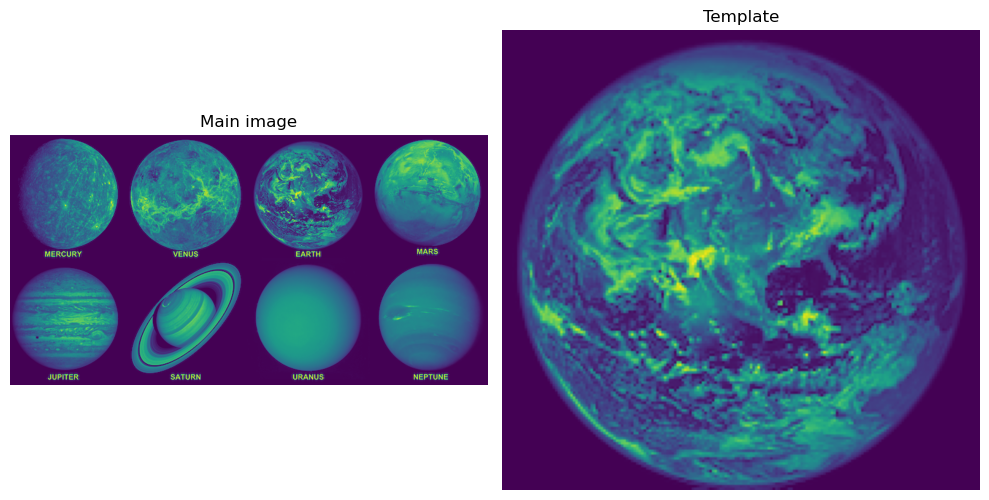

In [4]:
img = cv2.imread('solar system.png', 0)
template = cv2.imread('earth.png', 0)

plt.figure(figsize=(10,8))
plt.subplot(1,2,1)
plt.imshow(img)
plt.title('Main image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(template)
plt.title('Template')
plt.axis('off')
plt.tight_layout()
plt.show()

In [5]:
h, w = template.shape

methods = {
    "SAD": cv2.TM_SQDIFF,
    "SSD": cv2.TM_SQDIFF_NORMED,
    "CC": cv2.TM_CCORR,
    "NNC": cv2.TM_CCOEFF_NORMED
}

(391, 7)
(391, 7)
(590, 0)
(391, 7)


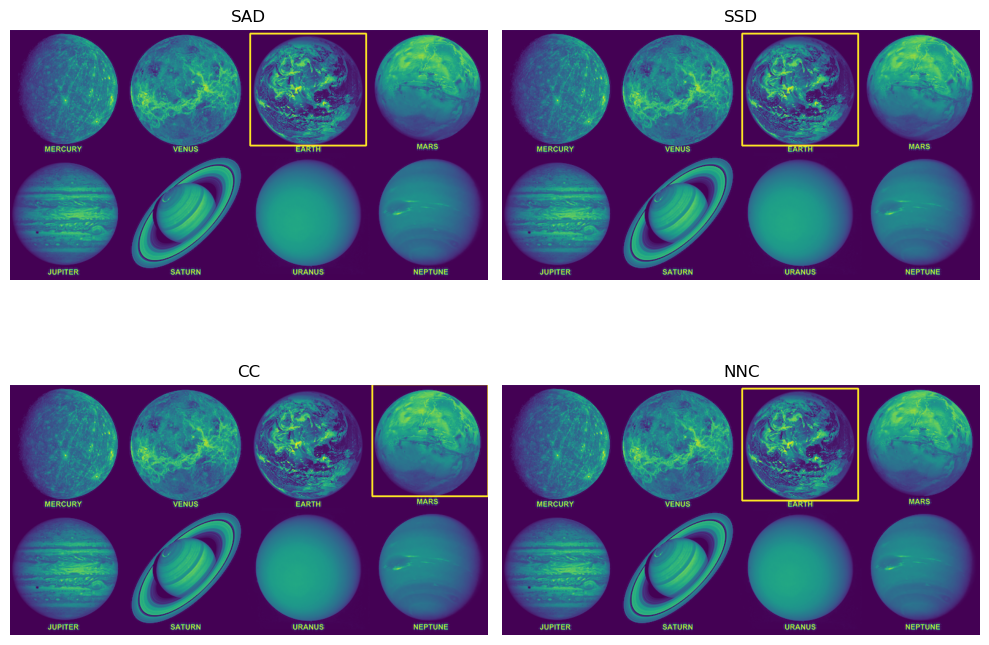

In [8]:
plt.figure(figsize=(10,8))

for i, (name, method) in enumerate(methods.items()):
    # Slide template over image
    result = cv2.matchTemplate(img, template, method)

    # Find best match
    min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(result)

    # Chose location depending on method
    if method in [cv2.TM_SQDIFF, cv2.TM_SQDIFF_NORMED]:
        top_left = min_loc
    else:
        top_left = max_loc
    print(top_left)

    bottom_right = (top_left[0] + w, top_left[1] + h)

    # Draw rectangle
    img_copy = img.copy()
    cv2.rectangle(img_copy, top_left, bottom_right, 255, 2)

    # Display it
    plt.subplot(2, 2, i+1)
    plt.imshow(img_copy)
    plt.title(name)
    plt.axis('off')

plt.tight_layout()
plt.show()

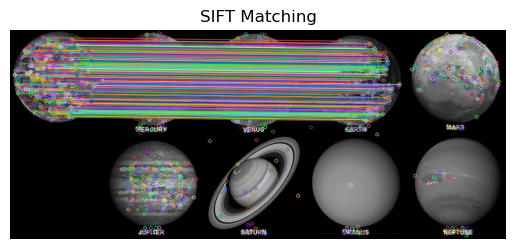

In [7]:
sift = cv2.SIFT_create()

kp1, des1 = sift.detectAndCompute(template, None)
kp2, des2 = sift.detectAndCompute(img, None)

bf = cv2.BFMatcher()
matches = bf.knnMatch(des1, des2, k=2)

good = []
for m, n in matches:
    if m.distance < 0.5 * n.distance:
        good.append(m)

result = cv2.drawMatches(template, kp1, img, kp2, good, None)

plt.imshow(result)
plt.title("SIFT Matching")
plt.axis('off')
plt.show()

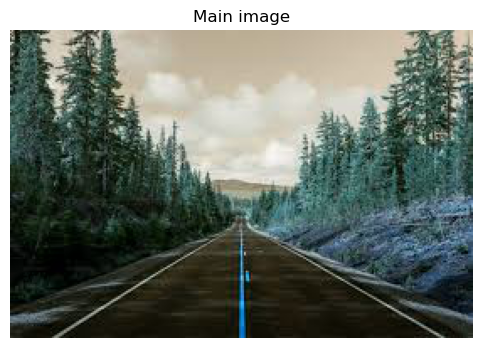

In [11]:
img = cv2.imread('road.jpeg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(10,4))
plt.imshow(img)
plt.title('Main image')
plt.axis('off')
plt.show()

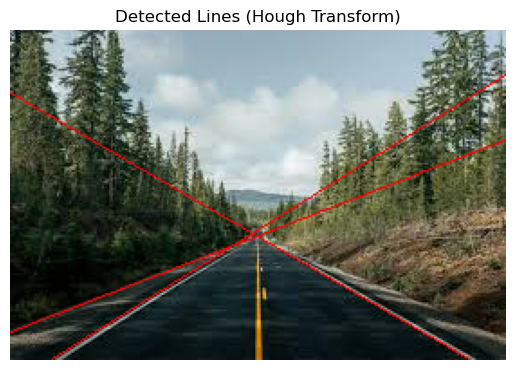

In [12]:
edges = cv2.Canny(gray, 50, 150)

lines = cv2.HoughLines(edges, 1, np.pi/180, 135)

img_lines = img.copy()

if lines is not None:
    for rho, theta in lines[:, 0]:
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a*rho
        y0 = b*rho

        x1 = int(x0 + 1000*(-b))
        y1 = int(y0 + 1000*(a))
        x2 = int(x0 - 1000*(-b))
        y2 = int(y0 - 1000*(a))

        cv2.line(img_lines, (x1, y1), (x2, y2), (0,0,255), 1)

# Display it
plt.imshow(cv2.cvtColor(img_lines, cv2.COLOR_BGR2RGB))
plt.title("Detected Lines (Hough Transform)")
plt.axis('off')
plt.show()